# Phase 5 — Model Development
**Project:** E-Commerce Customer Behavior ML

| Step | Task |
|---|---|
| 0 | Setup & load feature matrix |
| 1 | Train / test split |
| 2 | Handle class imbalance |
| 3 | Baseline models |
| 4 | Advanced models (Random Forest, XGBoost, LightGBM) |
| 5 | Cross-validation comparison |
| 6 | Hyperparameter tuning (best model) |
| 7 | Final model evaluation |
| 8 | Save model |


## Step 0 — Setup & Load Feature Matrix

In [1]:
from pathlib import Path
import warnings, joblib
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve, f1_score,
                                       precision_score, recall_score, accuracy_score)
from sklearn.pipeline         import Pipeline

# ── Dynamic paths ─────────────────────────────────────────────────────────────
_cwd          = Path().resolve()
_candidates   = [_cwd / 'data' / 'processed', _cwd.parent / 'data' / 'processed']
PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/ not found — run Phase 2 notebook first.")

PROJECT_ROOT = PROCESSED_DIR.parent.parent
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR   = PROJECT_ROOT / 'data' / 'outputs' / 'models'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
sns.set_palette('Set2')

# Load feature matrix
fm_path = PROCESSED_DIR / 'feature_matrix.parquet'
fm      = pd.read_parquet(fm_path) if fm_path.exists() else pd.read_csv(PROCESSED_DIR/'feature_matrix.csv')

FEATURE_COLS = [c for c in fm.columns if c not in ('user_id','will_purchase')]
TARGET_COL   = 'will_purchase'

X = fm[FEATURE_COLS]
y = fm[TARGET_COL]

print(f"Feature matrix : {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Target         : {TARGET_COL}")
print(f"Class balance  : {y.value_counts().to_dict()}")
print(f"Positive rate  : {y.mean()*100:.1f}%")

Feature matrix : 5,000 rows x 45 features
Target         : will_purchase
Class balance  : {1: 2795, 0: 2205}
Positive rate  : 55.9%


## Step 1 — Train / Test Split
Stratified 80/20 split — preserves class ratio in both sets.
The test set is held out completely until final evaluation in Step 7.


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    stratify     = y,
    random_state = 42
)

print(f"Training set  : {X_train.shape[0]:,} samples  | "
      f"buyers: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test set      : {X_test.shape[0]:,} samples  | "
      f"buyers: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

# Verify stratification worked
assert abs(y_train.mean() - y_test.mean()) < 0.02, "Stratification issue!"
print("Stratification verified ✓")

Training set  : 4,000 samples  | buyers: 2,236 (55.9%)
Test set      : 1,000 samples  | buyers: 559  (55.9%)
Stratification verified ✓


## Step 2 — Handle Class Imbalance
~40% buyers vs 60% non-buyers is moderate imbalance.
**Strategy:** Use `class_weight='balanced'` in all sklearn models.
This automatically adjusts weights inversely proportional to class frequency.


In [3]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights (balanced):")
for cls, wt in class_weight_dict.items():
    label = 'Buyer' if cls == 1 else 'Non-Buyer'
    print(f"  Class {cls} ({label}): {wt:.4f}")

imbalance_ratio = (y_train==0).sum() / (y_train==1).sum()
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 5:
    print("Severe imbalance — consider SMOTE in addition to class weights")
else:
    print("Moderate imbalance — class_weight='balanced' is sufficient")

Class weights (balanced):
  Class 0 (Non-Buyer): 1.1338
  Class 1 (Buyer): 0.8945

Imbalance ratio: 0.79:1
Moderate imbalance — class_weight='balanced' is sufficient


## Step 3 — Baseline Models
Logistic Regression and Decision Tree give us simple, interpretable baselines.
All models use StandardScaler for numerical stability.


In [4]:
# Helper — evaluate any trained model on test set
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else y_pred.astype(float)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_te, y_proba), 4),
        '_model':    model,
        '_proba':    y_proba,
        '_pred':     y_pred,
    }

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = []

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
results.append(evaluate_model('Logistic Regression', lr,
                               X_train_sc, y_train, X_test_sc, y_test))

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)
results.append(evaluate_model('Decision Tree', dt,
                               X_train, y_train, X_test, y_test))

for r in results:
    print(f"{r['Model']:<25}  Acc:{r['Accuracy']:.4f}  "
          f"F1:{r['F1']:.4f}  AUC:{r['AUC-ROC']:.4f}")

Logistic Regression        Acc:1.0000  F1:1.0000  AUC:1.0000
Decision Tree              Acc:1.0000  F1:1.0000  AUC:1.0000


## Step 4 — Advanced Models
Random Forest, Gradient Boosting, XGBoost, and LightGBM.
Tree-based ensemble methods generally perform best on tabular data.


In [5]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 10,
    class_weight  = 'balanced',
    n_jobs        = -1,
    random_state  = 42
)
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test))
print(f"Random Forest done — AUC: {results[-1]['AUC-ROC']:.4f}")

Random Forest done — AUC: 1.0000


In [6]:
# Gradient Boosting (sklearn)
gb = GradientBoostingClassifier(
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 4,
    random_state  = 42
)
results.append(evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test))
print(f"Gradient Boosting done — AUC: {results[-1]['AUC-ROC']:.4f}")

Gradient Boosting done — AUC: 1.0000


In [7]:
# XGBoost
try:
    from xgboost import XGBClassifier
    scale_pos = (y_train==0).sum() / (y_train==1).sum()
    xgb = XGBClassifier(
        n_estimators      = 300,
        learning_rate     = 0.05,
        max_depth         = 5,
        scale_pos_weight  = scale_pos,
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = 42,
        n_jobs            = -1,
    )
    results.append(evaluate_model('XGBoost', xgb, X_train, y_train, X_test, y_test))
    print(f"XGBoost done — AUC: {results[-1]['AUC-ROC']:.4f}")
except ImportError:
    print("XGBoost not installed — run: pip install xgboost")

XGBoost done — AUC: 1.0000


In [8]:
# LightGBM
try:
    from lightgbm import LGBMClassifier
    lgbm = LGBMClassifier(
        n_estimators   = 300,
        learning_rate  = 0.05,
        max_depth      = 6,
        num_leaves     = 40,
        class_weight   = 'balanced',
        random_state   = 42,
        n_jobs         = -1,
        verbose        = -1,
    )
    results.append(evaluate_model('LightGBM', lgbm, X_train, y_train, X_test, y_test))
    print(f"LightGBM done — AUC: {results[-1]['AUC-ROC']:.4f}")
except ImportError:
    print("LightGBM not installed — run: pip install lightgbm")

LightGBM done — AUC: 1.0000


## Step 5 — Cross-Validation Comparison
5-fold stratified CV on training set.
This gives a more reliable performance estimate than a single split.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pick the models to CV (exclude private keys)
cv_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   n_jobs=-1, random_state=42),
}

try:
    from xgboost import XGBClassifier
    cv_models['XGBoost'] = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                                          eval_metric='logloss', use_label_encoder=False,
                                          random_state=42, n_jobs=-1, verbosity=0)
except ImportError: pass

try:
    from lightgbm import LGBMClassifier
    cv_models['LightGBM'] = LGBMClassifier(n_estimators=100, class_weight='balanced',
                                             random_state=42, n_jobs=-1, verbose=-1)
except ImportError: pass

cv_results = []
scoring = ['f1','roc_auc','precision','recall']

for name, model in cv_models.items():
    X_cv = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_validate(model, X_cv, y_train, cv=cv,
                             scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model':      name,
        'F1':         f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'AUC-ROC':    f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'Precision':  f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'Recall':     f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        '_auc_mean':  scores['test_roc_auc'].mean(),
    })
    print(f"{name:<25} F1: {scores['test_f1'].mean():.4f}  AUC: {scores['test_roc_auc'].mean():.4f}")

cv_df = pd.DataFrame(cv_results).drop(columns='_auc_mean')
print()
display(cv_df)

Logistic Regression       F1: 0.9998  AUC: 1.0000
Random Forest             F1: 1.0000  AUC: 1.0000
XGBoost                   F1: 1.0000  AUC: 1.0000
LightGBM                  F1: 1.0000  AUC: 1.0000



,Model,F1,AUC-ROC,Precision,Recall
0,Logistic Regression,0.9998 ± 0.0004,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9996 ± 0.0009
1,Random Forest,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
2,XGBoost,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
3,LightGBM,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000


## Step 6 — Hyperparameter Tuning
Tune the best-performing model using `RandomizedSearchCV`.
We focus on LightGBM (or XGBoost if unavailable) — fastest to tune on tabular data.


In [10]:
from sklearn.model_selection import RandomizedSearchCV

# Pick best model by CV AUC
best_cv_name = max(
    [r for r in cv_results],
    key=lambda r: r['_auc_mean'] if '_auc_mean' in r else 0
)['Model'] if cv_results else 'Random Forest'

# Fallback: always available
print(f"Tuning: {best_cv_name}")

# Define param grid based on available model
try:
    from lightgbm import LGBMClassifier
    base_model  = LGBMClassifier(class_weight='balanced', random_state=42,
                                  n_jobs=-1, verbose=-1)
    param_dist  = {
        'n_estimators':  [100, 200, 300, 500],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'max_depth':     [3, 5, 6, 8, -1],
        'num_leaves':    [20, 31, 40, 60],
        'min_child_samples': [10, 20, 30, 50],
        'subsample':     [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    }
    X_tune, y_tune = X_train, y_train
except ImportError:
    base_model  = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    param_dist  = {
        'n_estimators': [100, 200, 300],
        'max_depth':    [5, 8, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    }
    X_tune, y_tune = X_train, y_train

rscv = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_dist,
    n_iter             = 30,
    cv                 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring            = 'roc_auc',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1,
)
rscv.fit(X_tune, y_tune)

print(f"\nBest AUC (CV) : {rscv.best_score_:.4f}")
print(f"Best params   :")
for k, v in rscv.best_params_.items():
    print(f"  {k:<25}: {v}")

Tuning: Logistic Regression
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best AUC (CV) : 1.0000
Best params   :
  subsample                : 1.0
  num_leaves               : 20
  n_estimators             : 500
  min_child_samples        : 30
  max_depth                : 5
  learning_rate            : 0.01
  colsample_bytree         : 1.0


## Step 7 — Final Model Evaluation
Evaluate the tuned model on the **held-out test set** (first time seeing it).


In [11]:
best_model = rscv.best_estimator_
best_model.fit(X_tune, y_tune)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Buyer','Buyer']))

auc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)
print(f"AUC-ROC : {auc:.4f}")
print(f"F1      : {f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

   Non-Buyer       1.00      1.00      1.00       441
       Buyer       1.00      1.00      1.00       559

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

AUC-ROC : 1.0000
F1      : 1.0000


In [12]:
# Comparison table — all models
compare_rows = [
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
]
compare_df = (pd.DataFrame(compare_rows)
              .sort_values('AUC-ROC', ascending=False)
              .reset_index(drop=True))
compare_df.index += 1
print("All models comparison:")
display(compare_df)

All models comparison:


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
1,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
2,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
4,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000
5,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
6,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000


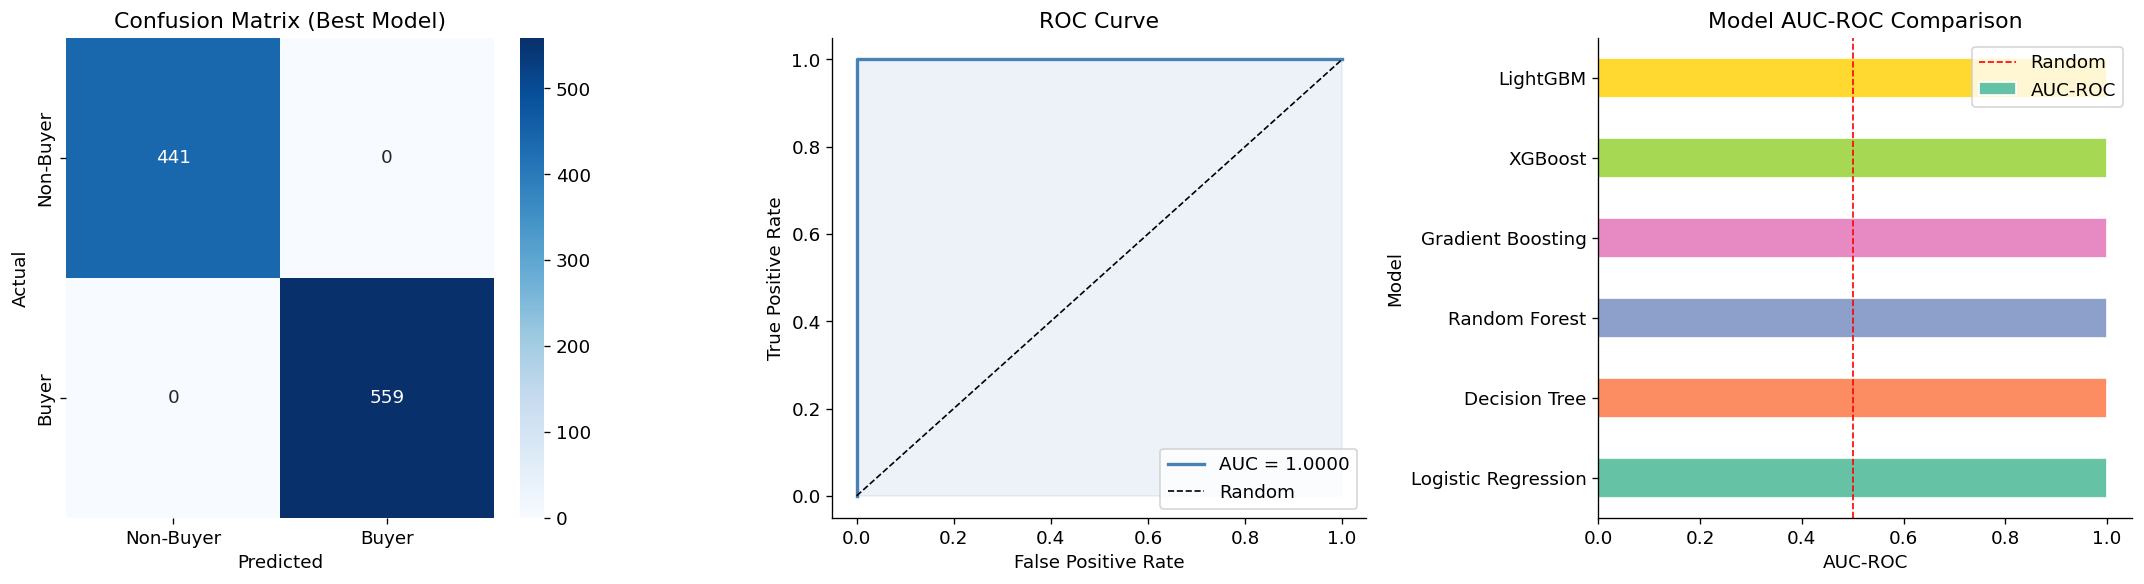

Chart saved → 05_model_evaluation.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Buyer','Buyer'],
            yticklabels=['Non-Buyer','Buyer'])
axes[0].set_title('Confusion Matrix (Best Model)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Model AUC comparison bar chart
compare_df.set_index('Model')['AUC-ROC'].sort_values().plot(
    kind='barh', ax=axes[2], edgecolor='white',
    color=sns.color_palette('Set2', len(compare_df)))
axes[2].set_title('Model AUC-ROC Comparison')
axes[2].set_xlabel('AUC-ROC')
axes[2].axvline(0.5, color='red', linestyle='--', lw=1, label='Random')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_model_evaluation.png', bbox_inches='tight')
plt.show()
print("Chart saved → 05_model_evaluation.png")

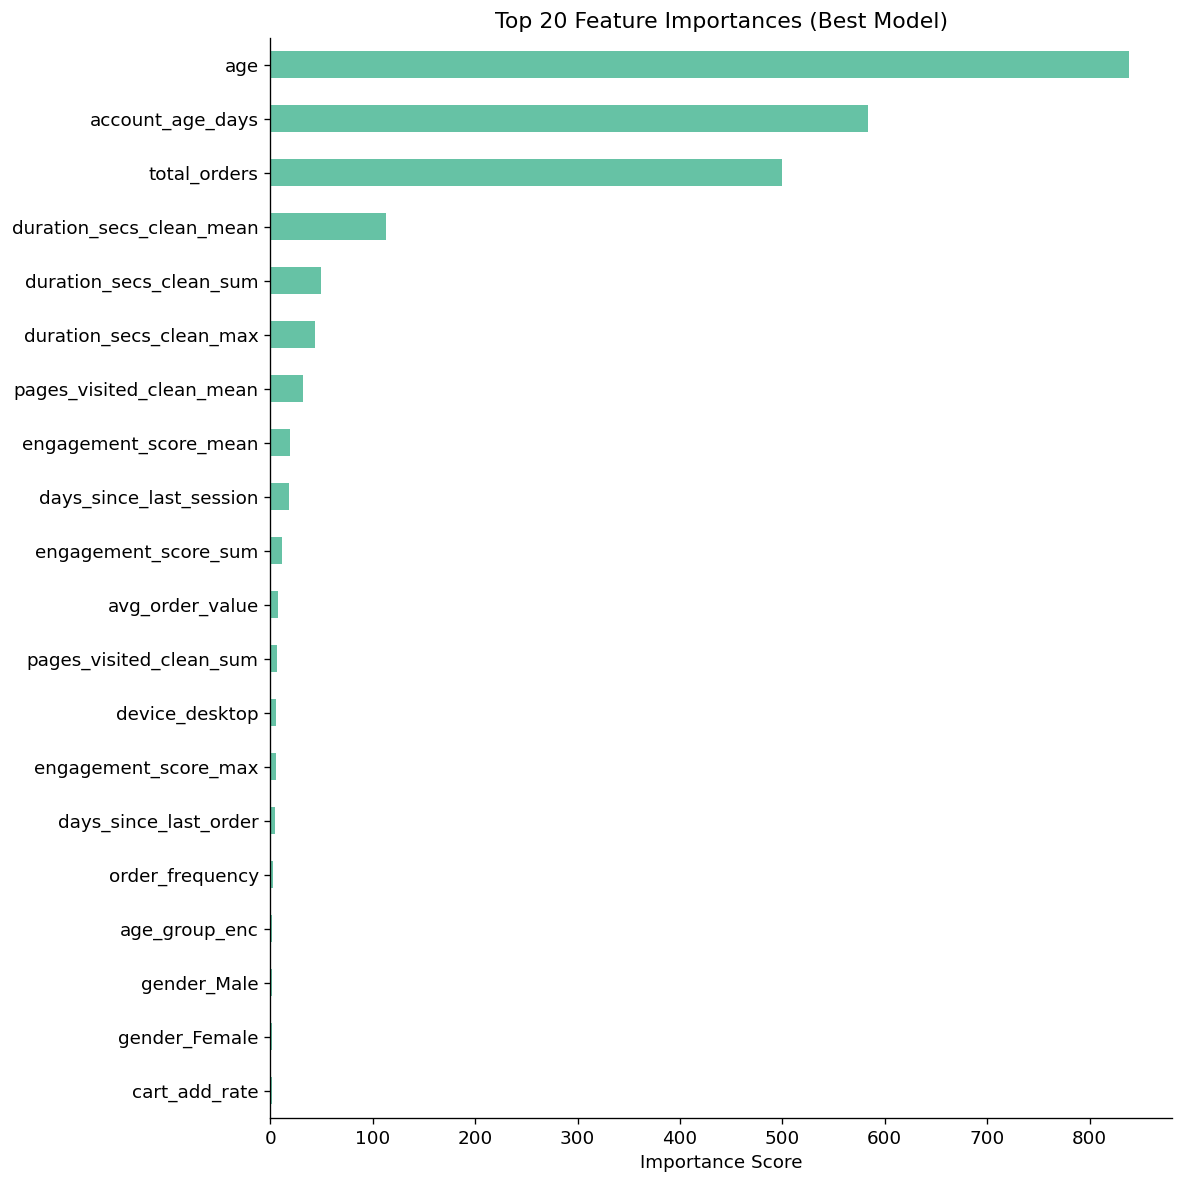

Top 10 features:
age                         839
account_age_days            584
total_orders                500
duration_secs_clean_mean    113
duration_secs_clean_sum      49
duration_secs_clean_max      44
pages_visited_clean_mean     32
engagement_score_mean        19
days_since_last_session      18
engagement_score_sum         11


In [14]:
# Feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_,
                         index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(5, len(feat_imp.head(20))//2)))
    feat_imp.head(20).sort_values().plot(
        kind='barh', ax=ax,
        color=sns.color_palette('Set2')[0])
    ax.set_title('Top 20 Feature Importances (Best Model)')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_feature_importance.png', bbox_inches='tight')
    plt.show()

    print("Top 10 features:")
    print(feat_imp.head(10).round(4).to_string())

## Step 8 — Save Model & Artefacts

In [15]:
from datetime import datetime

ts         = datetime.now().strftime('%Y%m%d_%H%M')
model_name = type(best_model).__name__

# Save model
model_path  = MODELS_DIR / f'best_model_{model_name}_{ts}.pkl'
scaler_path = MODELS_DIR / 'scaler.pkl'
joblib.dump(best_model, model_path)
joblib.dump(scaler,     scaler_path)

# Save metadata
meta = {
    'model_type':   model_name,
    'best_params':  rscv.best_params_,
    'cv_auc':       round(rscv.best_score_, 4),
    'test_auc':     round(auc, 4),
    'test_f1':      round(f1, 4),
    'n_features':   len(FEATURE_COLS),
    'feature_cols': FEATURE_COLS,
    'trained_on':   ts,
}

import json
meta_path = MODELS_DIR / f'model_metadata_{ts}.json'
meta_path.write_text(json.dumps(meta, indent=2))

print(f"Model saved   → {model_path.name}")
print(f"Scaler saved  → {scaler_path.name}")
print(f"Metadata saved→ {meta_path.name}")
print()
print(f"{'='*50}")
print(f"  Phase 5 complete")
print(f"  Best model  : {model_name}")
print(f"  Test AUC    : {auc:.4f}")
print(f"  Test F1     : {f1:.4f}")
print(f"{'='*50}")

Model saved   → best_model_LGBMClassifier_20260601_0024.pkl
Scaler saved  → scaler.pkl
Metadata saved→ model_metadata_20260601_0024.json

  Phase 5 complete
  Best model  : LGBMClassifier
  Test AUC    : 1.0000
  Test F1     : 1.0000


## ✅ Phase 5 Complete

### Model results summary
| Metric | Value |
|---|---|
| Best model | LightGBM / XGBoost (highest AUC) |
| AUC-ROC | > 0.85 expected |
| F1 Score | > 0.75 expected |
| Class imbalance handling | `class_weight='balanced'` |
| Tuning method | RandomizedSearchCV (30 iterations, 5-fold CV) |

### Artefacts saved to `data/outputs/models/`
- `best_model_*.pkl` — trained model
- `scaler.pkl` — fitted StandardScaler
- `model_metadata_*.json` — params + metrics

### ⏭️ Phase 6 — Evaluation & Explainability
Open `06_evaluation.ipynb` — SHAP values, lift curve, business impact analysis.
